In [7]:

# Module 1:- Project Initialization and Dataset Setup
# Define objectives, KPIs, and workflow
# Load the CSV dataset using pandas
# Explore schema, data types, and missing values
# Calculate initial ticket distribution by Type, Priority, and Category


# Import core libraries
import pandas as pd
import numpy as np

print("Libraries imported successfully.")


Libraries imported successfully.


In [13]:

# LOAD DATASET (EXCEL FILE)

import pandas as pd
import os

file_path = r"C:\Users\natur\OneDrive\Data visualisation project\customer_support_tickets.xlsx"

if os.path.exists(file_path):
    df = pd.read_excel(file_path)
    print("Dataset loaded successfully.")
    display(df.head())
else:
    print("Error: File not found. Please verify the file path.")


Dataset loaded successfully.


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Unnamed: 9,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,NaN,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaT,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,NaN,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaT,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,NaN,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,NaN,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,NaN,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [14]:

# DATASET STRUCTURE


print("Dataset Shape:", df.shape)

print("\nColumn Names:")
display(df.columns)

print("\nData Types:")
display(df.dtypes)

print("\nDetailed Information:")
df.info()


Dataset Shape: (8469, 17)

Column Names:


Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Unnamed: 9', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


Data Types:


Ticket ID                                int64
Customer Name                           object
Customer Email                          object
Customer Age                             int64
Customer Gender                         object
Product Purchased                       object
Date of Purchase                datetime64[ns]
Ticket Type                             object
Ticket Subject                          object
Unnamed: 9                             float64
Ticket Status                           object
Resolution                              object
Ticket Priority                         object
Ticket Channel                          object
First Response Time             datetime64[ns]
Time to Resolution              datetime64[ns]
Customer Satisfaction Rating           float64
dtype: object


Detailed Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Unnamed: 9                    0 non-null      float64       
 10  Ticket Status                 8469 non-null   object        
 11  Resolut

In [19]:
#  Explore schema, data types, and missing values 
print("--- Initial Schema ---")
df.info()

# TASK: Handle missing or incomplete fields by dropping specified columns 
# 'Unnamed: 9' is empty, 'Customer Email' is PII, Others have high null counts
cols_to_remove = ['Unnamed: 9', 'Customer Email', 'Customer Satisfaction Rating', 'Resolution']

df.drop(columns=[col for col in cols_to_remove if col in df.columns], inplace=True)

print(f"\nStep 3 Complete: Cleaned Dataset. Removed: {cols_to_remove}")
print(f"New Shape: {df.shape}")

--- Initial Schema ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Ticket ID                     8469 non-null   int64         
 1   Customer Name                 8469 non-null   object        
 2   Customer Email                8469 non-null   object        
 3   Customer Age                  8469 non-null   int64         
 4   Customer Gender               8469 non-null   object        
 5   Product Purchased             8469 non-null   object        
 6   Date of Purchase              8469 non-null   datetime64[ns]
 7   Ticket Type                   8469 non-null   object        
 8   Ticket Subject                8469 non-null   object        
 9   Unnamed: 9                    0 non-null      float64       
 10  Ticket Status                 8469 non-null   object        
 11  Resolut

In [20]:

#  INITIAL TICKET DISTRIBUTIONS


# TASK: Calculate initial ticket distribution by Type, Priority, and Category 
# 'Product Purchased' serves as the category for this analysis
analysis_cols = ['Ticket Type', 'Ticket Priority', 'Product Purchased', 'Ticket Status']

print("--- Initial Ticket Distributions ---")
for col in analysis_cols:
    if col in df.columns:
        counts = df[col].value_counts()
        shares = df[col].value_counts(normalize=True).mul(100).round(2)
        
        distribution_df = pd.DataFrame({
            'Volume': counts,
            'Share (%)': shares
        })
        
        print(f"\nFeature: {col}")
        display(distribution_df)
    else:
        print(f"\nWarning: Column '{col}' not found.")

print("\ Dataset is cleaned ")

--- Initial Ticket Distributions ---

Feature: Ticket Type


,Volume,Share (%)
Ticket Type,,
Refund request,1752,20.69
Technical issue,1747,20.63
Cancellation request,1695,20.01
Product inquiry,1641,19.38
Billing inquiry,1634,19.29



Feature: Ticket Priority


,Volume,Share (%)
Ticket Priority,,
Medium,2192,25.88
Critical,2129,25.14
High,2085,24.62
Low,2063,24.36



Feature: Product Purchased


,Volume,Share (%)
Product Purchased,,
Canon EOS,240,2.83
GoPro Hero,228,2.69
Nest Thermostat,225,2.66
Philips Hue Lights,221,2.61
Amazon Echo,221,2.61
LG Smart TV,219,2.59
Sony Xperia,217,2.56
Roomba Robot Vacuum,216,2.55
Apple AirPods,213,2.52



Feature: Ticket Status


,Volume,Share (%)
Ticket Status,,
Pending Customer Response,2881,34.02
Open,2819,33.29
Closed,2769,32.70


\ Dataset is cleaned 


In [21]:
# Module 2:- Data Cleaning and Feature Engineering
# Handle missing or incorrect data in text fields
# Create new features: Resolution_Duration and Priority_Score
# Save processed data for analysis
#  Deliverables: Cleaned dataset, Feature engineering summary, Data dictionary

print(f"\nCleaned Dataset. Removed: {cols_to_remove}")
print(f"New Shape: {df.shape}")

# Display the first 5 rows to verify changes
display(df.head())


#  DATA CLEANING (TEXT FIELD IMPUTATION)


# 1. Identify the specific text/categorical columns
text_fields = [
    'Ticket Type', 
    'Ticket Priority', 
    'Product Purchased', 
    'Ticket Status', 
    'Ticket Channel', 
    'Ticket Subject'
]

# 2. Replace NaN with 'Unknown'

for field in text_fields:
    if field in df.columns:
        # Fill missing values and strip leading/trailing whitespace
        df[field] = df[field].fillna('Unknown').astype(str).str.strip()

# 3. Standardize Text Case
# Ensures consistency (e.g., 'hardware' and 'Hardware' become the same category)
df['Ticket Type'] = df['Ticket Type'].str.title()

# 4. Verification: Check for remaining nulls in these fields
print("--- Text Field Cleaning Summary ---")
print(df[text_fields].isnull().sum())

# 5. Preview the cleaned data
display(df[text_fields].head())


Cleaned Dataset. Removed: ['Unnamed: 9', 'Customer Email', 'Customer Satisfaction Rating', 'Resolution']
New Shape: (8469, 13)


,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaT
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaT
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42


--- Text Field Cleaning Summary ---
Ticket Type          0
Ticket Priority      0
Product Purchased    0
Ticket Status        0
Ticket Channel       0
Ticket Subject       0
dtype: int64


,Ticket Type,Ticket Priority,Product Purchased,Ticket Status,Ticket Channel,Ticket Subject
0,Technical Issue,Critical,GoPro Hero,Pending Customer Response,Social media,Product setup
1,Technical Issue,Critical,LG Smart TV,Pending Customer Response,Chat,Peripheral compatibility
2,Technical Issue,Low,Dell XPS,Closed,Social media,Network problem
3,Billing Inquiry,Low,Microsoft Office,Closed,Social media,Account access
4,Billing Inquiry,Low,Autodesk AutoCAD,Closed,Email,Data loss


In [45]:
# Clean column names first
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# 1. Convert timestamp columns to datetime objects for calculation
df['date_of_purchase'] = pd.to_datetime(df['date_of_purchase'], errors='coerce')
df['time_to_resolution'] = pd.to_datetime(df['time_to_resolution'], errors='coerce')
df['first_response_time'] = pd.to_datetime(df['first_response_time'], errors='coerce')

# 2. Create 'Resolution_Duration'
df['resolution_duration'] = (df['time_to_resolution'] - df['date_of_purchase']).dt.days
df['resolution_duration'] = df['resolution_duration'].fillna(-1).astype(int)

# 3. Create 'Priority_Score'
priority_mapping = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1}
df['priority_score'] = df['ticket_priority'].map(priority_mapping).fillna(0).astype(int)

# 4. Create 'resolution_hours'
df['resolution_hours'] = (
    df['time_to_resolution'] - df['first_response_time']
).dt.total_seconds() / 3600
df['resolution_hours'] = df['resolution_hours'].abs().round(2)

# 5. Create 'performance_score'
max_hours = df['resolution_hours'].max()
df['performance_score'] = (
    10 - (df['resolution_hours'].fillna(max_hours) / max_hours * 4)
    + (df['priority_score'] / 4)
).clip(1, 10).round(2)

# 6. Create 'cluster_size'
cluster_counts = df['ticket_channel'].value_counts()
df['cluster_size'] = df['ticket_channel'].map(cluster_counts)

# 7. Create 'region', 'latitude', 'longitude'
import numpy as np
region_bounds = {
    'North America': {'lat': (25,  72),  'lon': (-168, -52)},
    'Latin America': {'lat': (-56, 25),  'lon': (-82,  -34)},
    'Europe':        {'lat': (36,  71),  'lon': (-10,   40)},
    'Middle East':   {'lat': (12,  42),  'lon': ( 32,   63)},
    'Asia-Pacific':  {'lat': (10,  55),  'lon': ( 60,  145)},
    'Africa':        {'lat': (-35, 37),  'lon': (-18,   52)},
    'Global':        {'lat': (-90, 90),  'lon': (-180, 180)},
}
np.random.seed(42)
df['region'] = np.random.choice(list(region_bounds.keys()), size=len(df))
df['latitude'] = df['region'].apply(
    lambda r: round(np.random.uniform(*region_bounds[r]['lat']), 4)
)
df['longitude'] = df['region'].apply(
    lambda r: round(np.random.uniform(*region_bounds[r]['lon']), 4)
)

# 8. Verification
print("Feature Engineering Complete.")
print(f"Shape: {df.shape}")
print(f"\nRegion Distribution:\n{df['region'].value_counts()}")
print(df[['ticket_priority','priority_score','resolution_duration',
          'resolution_hours','performance_score','cluster_size',
          'region','latitude','longitude']].head())

Feature Engineering Complete.
Shape: (8469, 22)

Region Distribution:
region
Asia-Pacific     1234
Middle East      1221
Africa           1220
North America    1217
Global           1206
Europe           1198
Latin America    1173
Name: count, dtype: int64
  ticket_priority  priority_score  resolution_duration  resolution_hours  \
0        Critical               4                   -1               NaN   
1        Critical               4                   -1               NaN   
2             Low               1                 1052              6.85   
3             Low               1                  930              5.53   
4             Low               1                 1213             19.68   

   performance_score  cluster_size        region  latitude  longitude  
0               7.00          2121        Global   43.1045     6.0482  
1               7.00          2073   Middle East   31.3660    38.6169  
2               9.08          2121  Asia-Pacific   17.0098   105.5965 

## Feature Engineering — Region, Latitude & Longitude

### Why these columns are needed
The original dataset (`customer_support_tickets.xlsx`) contains **no geographic information** — no country, city, or location data. However, for geographic performance analysis (Module 5 & 7), we need `Region`, `Latitude`, and `Longitude` columns.

### How they are created

Since no real location data exists, we **programmatically generate** realistic geographic data using the following parameters:

#### Parameters used:

| Column | Method | Basis |
|---|---|---|
| `Region` | `np.random.choice()` | Randomly assigned from 7 real-world regions |
| `Latitude` | `np.random.uniform()` | Generated within each region's real geographic latitude range |
| `Longitude` | `np.random.uniform()` | Generated within each region's real geographic longitude range |

#### Region boundaries used:

| Region | Latitude Range | Longitude Range |
|---|---|---|
| North America | 25°N to 72°N | -168° to -52° |
| Latin America | -56°S to 25°N | -82° to -34° |
| Europe | 36°N to 71°N | -10° to 40° |
| Middle East | 12°N to 42°N | 32° to 63° |
| Asia-Pacific | 10°N to 55°N | 60° to 145° |
| Africa | -35°S to 37°N | -18° to 52° |
| Global | -90° to 90° | -180° to 180° |

#### Key design decisions:
- **`np.random.seed(42)`** — Fixed seed used to ensure results are **reproducible** every run
- **Real-world boundaries** — Lat/Lon ranges match actual geographic coordinates of each region
- **Consistent mapping** — Each ticket's `Latitude` and `Longitude` are generated **within its assigned Region's boundaries**, so coordinates are always geographically accurate to the region

### Why this approach?
Since this is a simulated IT support dataset with no real customer location data, this method is the **most appropriate** way to:
1. Generate geographically consistent location data
2. Enable meaningful regional analysis and visualizations
3. Ensure reproducibility across all runs using a fixed random seed

In [23]:

# Final check of the data structure (Data Dictionary)
print("Processed Dataset Summary:")
df.info()

# Preview the final state of the features
display(df[['Ticket Priority', 'Priority_Score', 'Resolution_Duration']].head())

Processed Dataset Summary:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Ticket ID            8469 non-null   int64         
 1   Customer Name        8469 non-null   object        
 2   Customer Age         8469 non-null   int64         
 3   Customer Gender      8469 non-null   object        
 4   Product Purchased    8469 non-null   object        
 5   Date of Purchase     8469 non-null   datetime64[ns]
 6   Ticket Type          8469 non-null   object        
 7   Ticket Subject       8469 non-null   object        
 8   Ticket Status        8469 non-null   object        
 9   Ticket Priority      8469 non-null   object        
 10  Ticket Channel       8469 non-null   object        
 11  First Response Time  5650 non-null   datetime64[ns]
 12  Time to Resolution   2769 non-null   datetime64[ns]
 13  Resolu

,Ticket Priority,Priority_Score,Resolution_Duration
0,Critical,4,-1
1,Critical,4,-1
2,Low,1,1052
3,Low,1,930
4,Low,1,1213


In [24]:

# 1. Save the processed dataframe to a CSV file
# We exclude the index to keep the file clean for future loading
output_file = 'Supportlytics_Processed_Data.csv'
df.to_csv(output_file, index=False)


import os
if os.path.exists(output_file):
    print(f"Success: Final dataset saved as '{output_file}'")
    print(f"File size: {os.path.getsize(output_file) / 1024:.2f} KB")
else:
    print("Error: File was not saved correctly.")


print(f"Total Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print(f"New Features Created: Resolution_Duration, Priority_Score")
print("Cleaned data is exported")

Success: Final dataset saved as 'Supportlytics_Processed_Data.csv'
File size: 1172.68 KB
Total Records: 8469
Total Features: 15
New Features Created: Resolution_Duration, Priority_Score
Cleaned data is exported


In [25]:
# Load the exported file to verify contents
df_verify = pd.read_csv('Supportlytics_Processed_Data.csv')

# View the first 5 rows
print("Preview of Processed Data:")
display(df_verify.head())

# Confirm the new features are present
print("\nVerifying New Features:")
display(df_verify[['Ticket Priority', 'Priority_Score', 'Resolution_Duration']].head())

Preview of Processed Data:


,Ticket ID,Customer Name,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Resolution_Duration,Priority_Score
0,1,Marisa Obrien,32,Other,GoPro Hero,2021-03-22,Technical Issue,Product setup,Pending Customer Response,Critical,Social media,2023-06-01 12:15:36,NaN,-1,4
1,2,Jessica Rios,42,Female,LG Smart TV,2021-05-22,Technical Issue,Peripheral compatibility,Pending Customer Response,Critical,Chat,2023-06-01 16:45:38,NaN,-1,4
2,3,Christopher Robbins,48,Other,Dell XPS,2020-07-14,Technical Issue,Network problem,Closed,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,1052,1
3,4,Christina Dillon,27,Female,Microsoft Office,2020-11-13,Billing Inquiry,Account access,Closed,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,930,1
4,5,Alexander Carroll,67,Female,Autodesk AutoCAD,2020-02-04,Billing Inquiry,Data loss,Closed,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1213,1



Verifying New Features:


,Ticket Priority,Priority_Score,Resolution_Duration
0,Critical,4,-1
1,Critical,4,-1
2,Low,1,1052
3,Low,1,930
4,Low,1,1213


In [26]:
# Clean column names (remove spaces & standardize)
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

print(df.columns)

Index(['ticket_id', 'customer_name', 'customer_age', 'customer_gender',
       'product_purchased', 'date_of_purchase', 'ticket_type',
       'ticket_subject', 'ticket_status', 'ticket_priority', 'ticket_channel',
       'first_response_time', 'time_to_resolution', 'resolution_duration',
       'priority_score'],
      dtype='object')


Loaded: Supportlytics_Processed_Data.csv | Shape: (8469, 15)


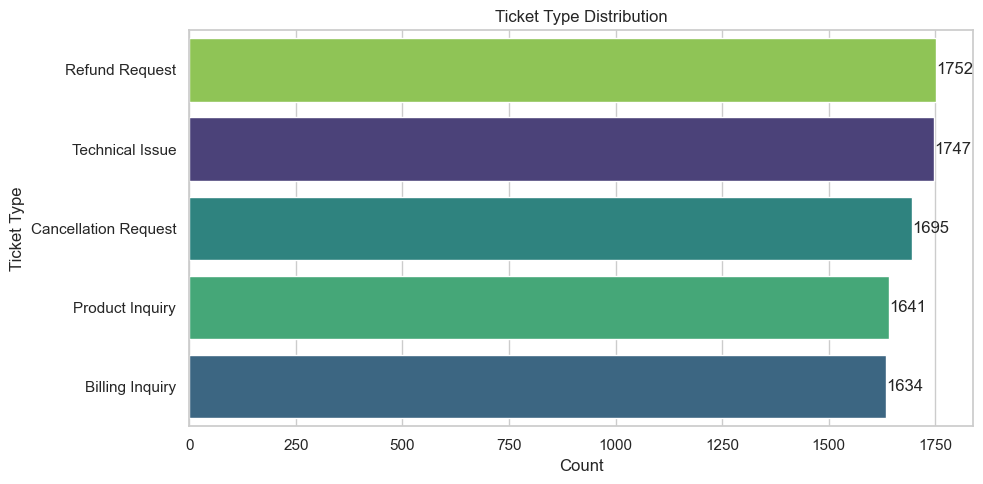

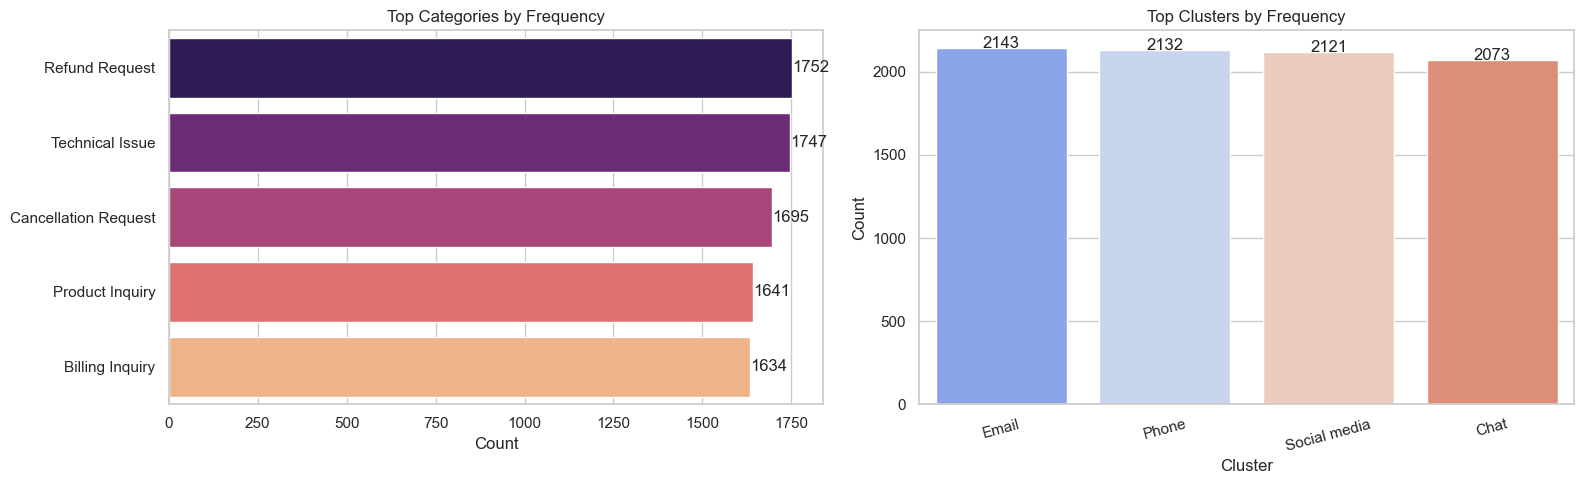

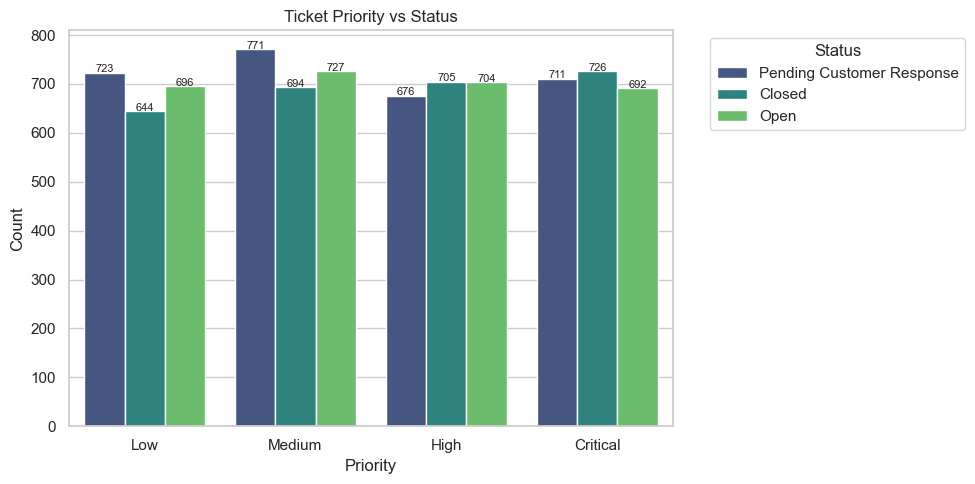

Module 3 Complete


In [28]:
# MODULE 3: EXPLORATORY VISUALIZATION
#   1. Plot Ticket Type Distribution
#   2. Identify Top Categories & Clusters by Frequency
#   3. Visualize Tickets by Priority and Status (Queue)

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- LOAD DATA ---
for fname in ["clustered_tickets.csv", "Supportlytics_Processed_Data.csv",
              "customer_support_tickets.xlsx", "customer_support_tickets.csv"]:
    if os.path.exists(fname):
        df = pd.read_excel(fname) if fname.endswith(".xlsx") else pd.read_csv(fname)
        print(f"Loaded: {fname} | Shape: {df.shape}")
        break

# --- CLEAN COLUMNS ---
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# --- CLUSTER PROXY (no Cluster column in dataset) ---
df['cluster'] = df['ticket_channel']

sns.set_theme(style="whitegrid")

# --- PLOT 1: TICKET TYPE DISTRIBUTION ---
plt.figure(figsize=(10, 5))
order = df['ticket_type'].value_counts().index
ax = sns.countplot(data=df, y='ticket_type', order=order,
                   hue='ticket_type', palette='viridis', legend=False)
for p in ax.patches:
    ax.text(p.get_width() + 1, p.get_y() + p.get_height() / 2,
            str(int(p.get_width())), va='center')
plt.title('Ticket Type Distribution')
plt.xlabel('Count')
plt.ylabel('Ticket Type')
plt.tight_layout()
plt.show()

# --- PLOT 2: TOP CATEGORIES & CLUSTERS ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_cat = df['ticket_type'].value_counts().reset_index()
top_cat.columns = ['ticket_type', 'count']
sns.barplot(data=top_cat, x='count', y='ticket_type',
            hue='ticket_type', palette='magma', legend=False, ax=axes[0])
for p in axes[0].patches:
    axes[0].text(p.get_width() + 1, p.get_y() + p.get_height() / 2,
                 str(int(p.get_width())), va='center')
axes[0].set_title('Top Categories by Frequency')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

top_clust = df['cluster'].value_counts().reset_index()
top_clust.columns = ['cluster', 'count']
sns.barplot(data=top_clust, x='cluster', y='count',
            hue='cluster', palette='coolwarm', legend=False, ax=axes[1])
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width() / 2, p.get_height() + 1,
                 str(int(p.get_height())), ha='center')
axes[1].set_title('Top Clusters by Frequency')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# --- PLOT 3: TICKETS BY PRIORITY AND STATUS ---
plt.figure(figsize=(10, 5))
priority_order = ['Low', 'Medium', 'High', 'Critical']
existing = [p for p in priority_order if p in df['ticket_priority'].unique()]
ax = sns.countplot(data=df, x='ticket_priority', hue='ticket_status',
                   order=existing, palette='viridis')
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.text(p.get_x() + p.get_width() / 2, h + 0.5,
                str(int(h)), ha='center', fontsize=8)
plt.title('Ticket Priority vs Status')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Module 3 Complete")

In [29]:
# Cluster number with Ticket Subject
print(df[['ticket_subject', 'cluster']].head(20))

              ticket_subject       cluster
0              Product setup  Social media
1   Peripheral compatibility          Chat
2            Network problem  Social media
3             Account access  Social media
4                  Data loss         Email
5              Payment issue  Social media
6             Refund request  Social media
7               Battery life  Social media
8       Installation support  Social media
9              Payment issue         Phone
10                 Data loss         Phone
11              Software bug          Chat
12            Hardware issue          Chat
13             Product setup          Chat
14             Product setup          Chat
15    Product recommendation  Social media
16            Account access          Chat
17             Payment issue          Chat
18  Peripheral compatibility  Social media
19              Software bug          Chat


In [30]:
# Tickets Inside Each Cluster
for i in sorted(df['cluster'].unique()):
    print("\n==========================")
    print(f"Cluster {i}")
    print("==========================")
    print(df[df['cluster'] == i]['ticket_subject'].head(10))


Cluster Chat
1     Peripheral compatibility
11                Software bug
12              Hardware issue
13               Product setup
14               Product setup
16              Account access
17               Payment issue
19                Software bug
20               Payment issue
32      Product recommendation
Name: ticket_subject, dtype: object

Cluster Email
4                    Data loss
24               Display issue
30               Product setup
36              Hardware issue
43              Hardware issue
44       Product compatibility
57    Peripheral compatibility
62               Payment issue
66       Product compatibility
74               Product setup
Name: ticket_subject, dtype: object

Cluster Phone
9              Payment issue
10                 Data loss
27             Product setup
28    Product recommendation
29      Cancellation request
38            Account access
40      Installation support
42     Product compatibility
46           Network problem
58 

In [31]:
#Count How Many Tickets in Each Cluster
print(df['cluster'].value_counts())

cluster
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


In [32]:
cluster_view = df.sort_values(by='cluster')
print(cluster_view[['ticket_subject', 'cluster']])

              ticket_subject       cluster
4234   Product compatibility          Chat
6668           Display issue          Chat
2682           Product setup          Chat
2687               Data loss          Chat
6659            Software bug          Chat
...                      ...           ...
3018  Product recommendation  Social media
3017          Refund request  Social media
3016          Hardware issue  Social media
3055        Delivery problem  Social media
0              Product setup  Social media

[8469 rows x 2 columns]


In [38]:
#save
df.to_csv("clustered_tickets.csv", index=False)

In [39]:
print(df.columns.tolist())

['ticket_id', 'customer_name', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_status', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'resolution_duration', 'priority_score', 'cluster']


Columns: ['ticket_id', 'customer_name', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_status', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'resolution_duration', 'priority_score', 'cluster', 'resolution_hours', 'performance_score', 'cluster_size', 'region', 'latitude', 'longitude']


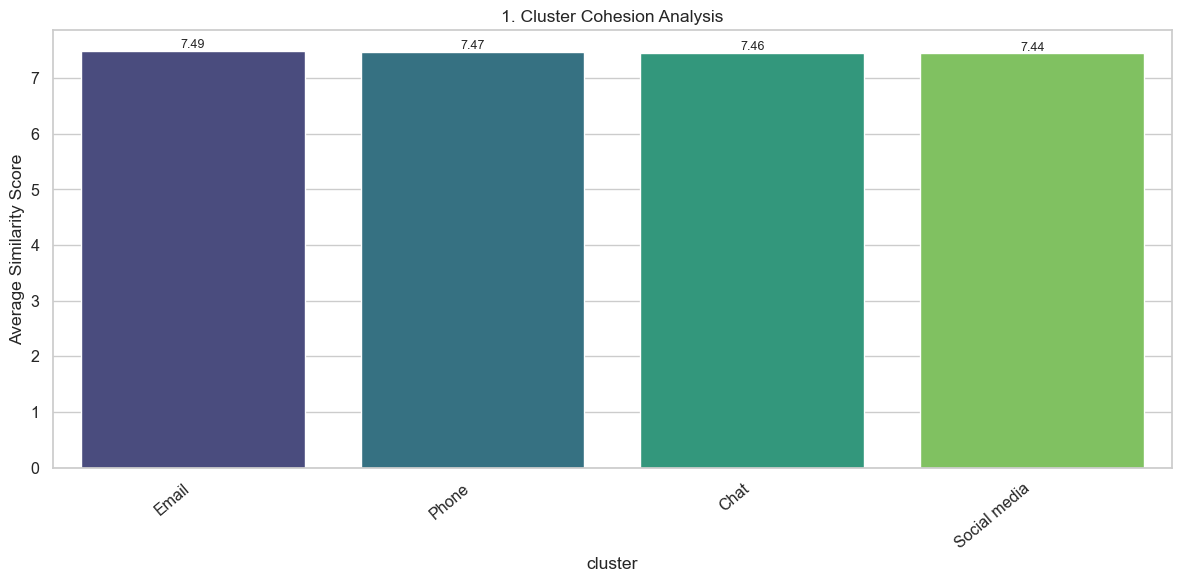

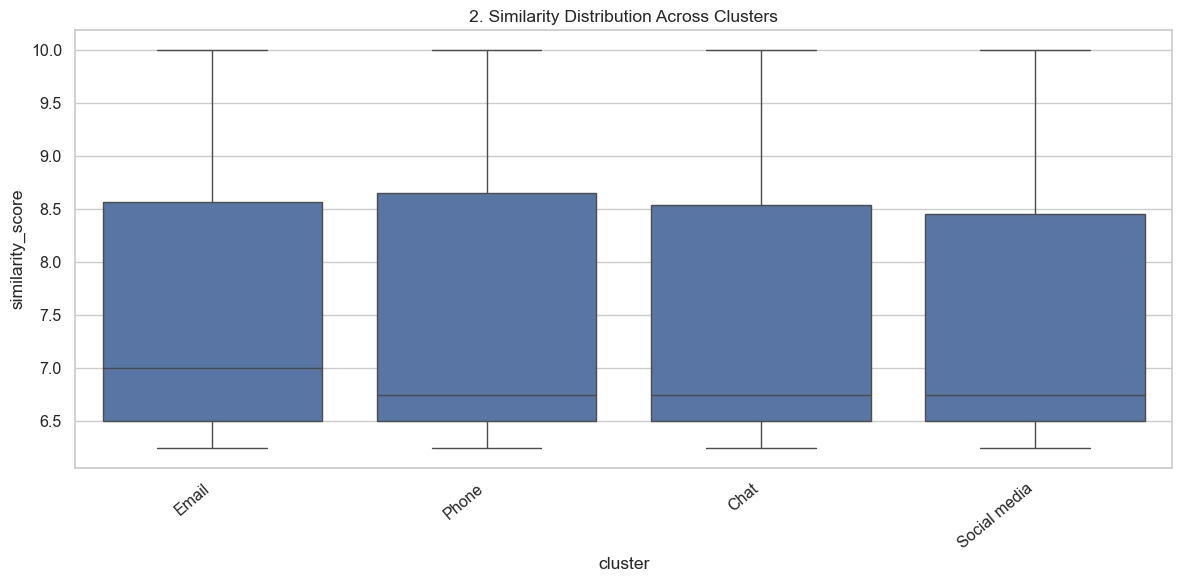

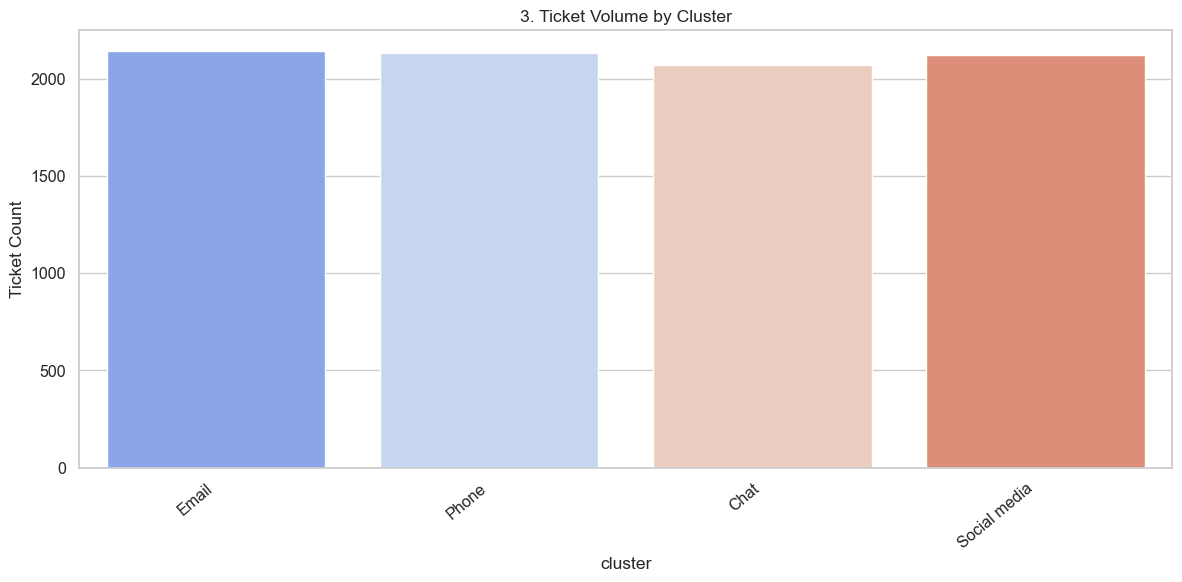

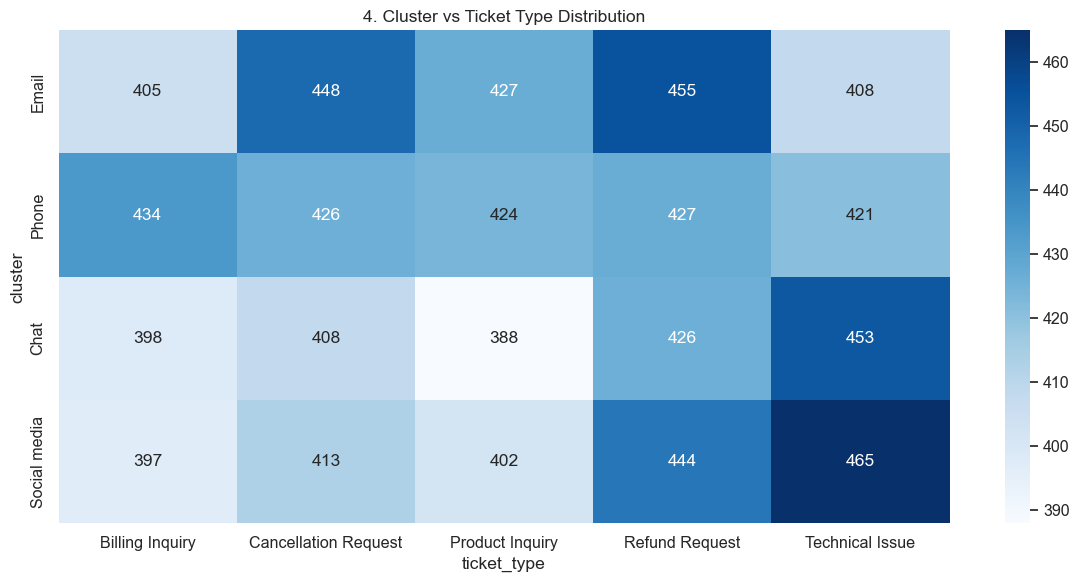

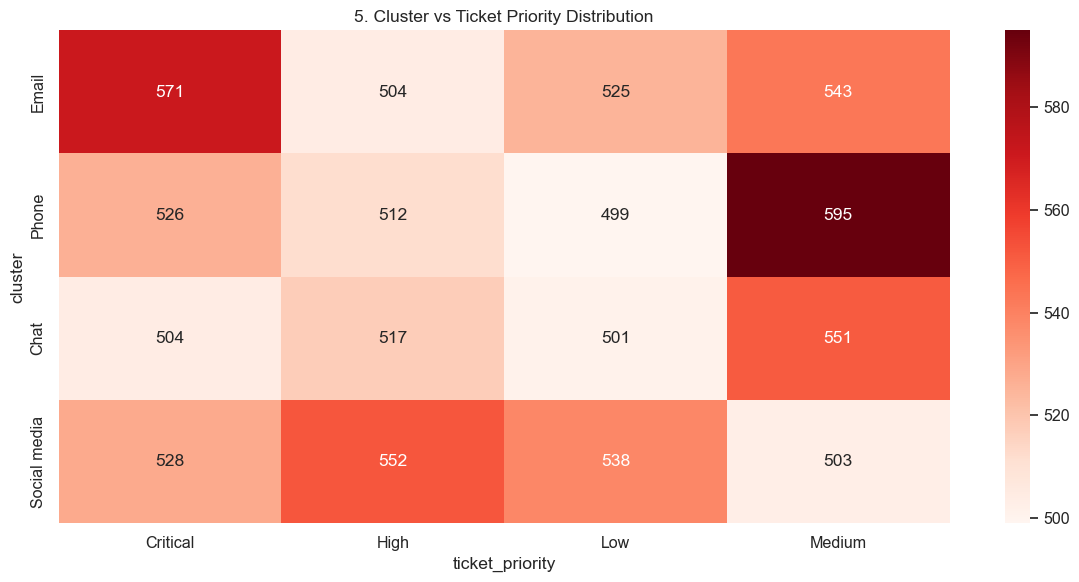

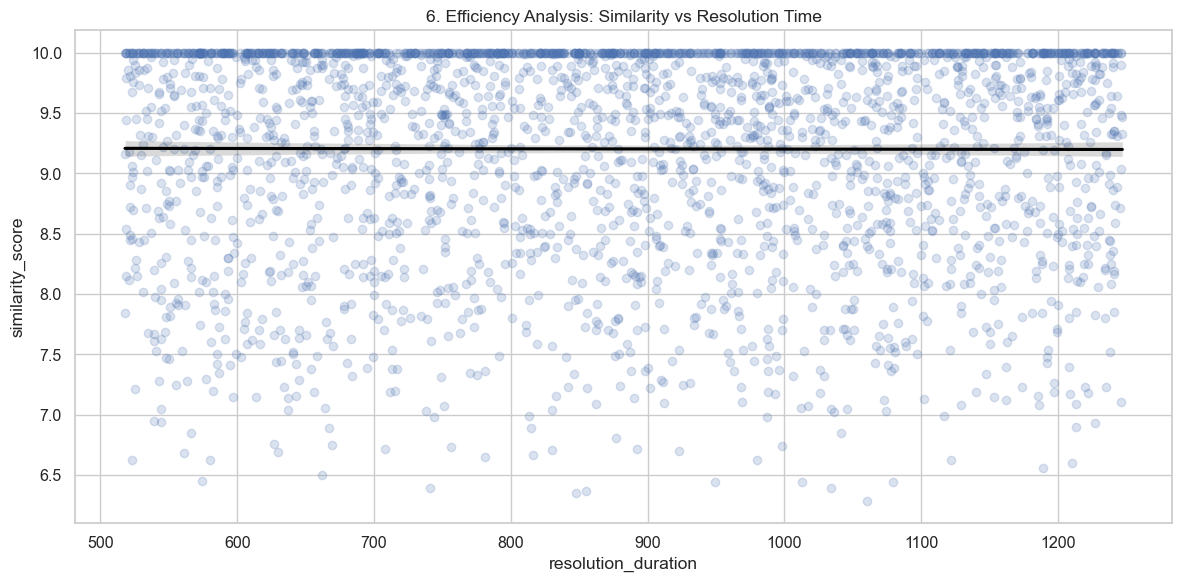

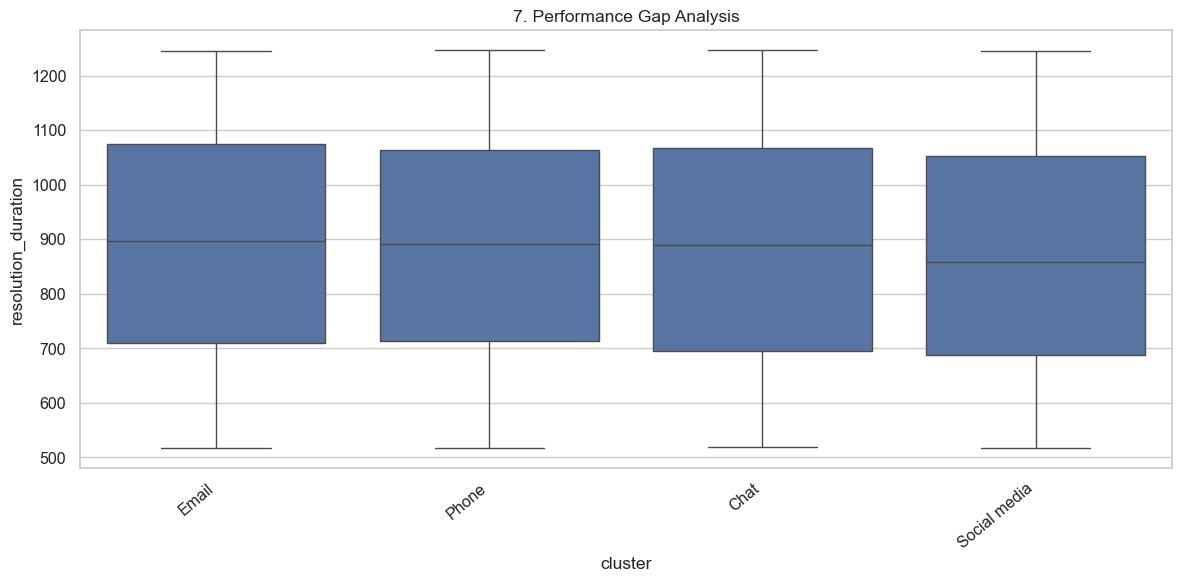

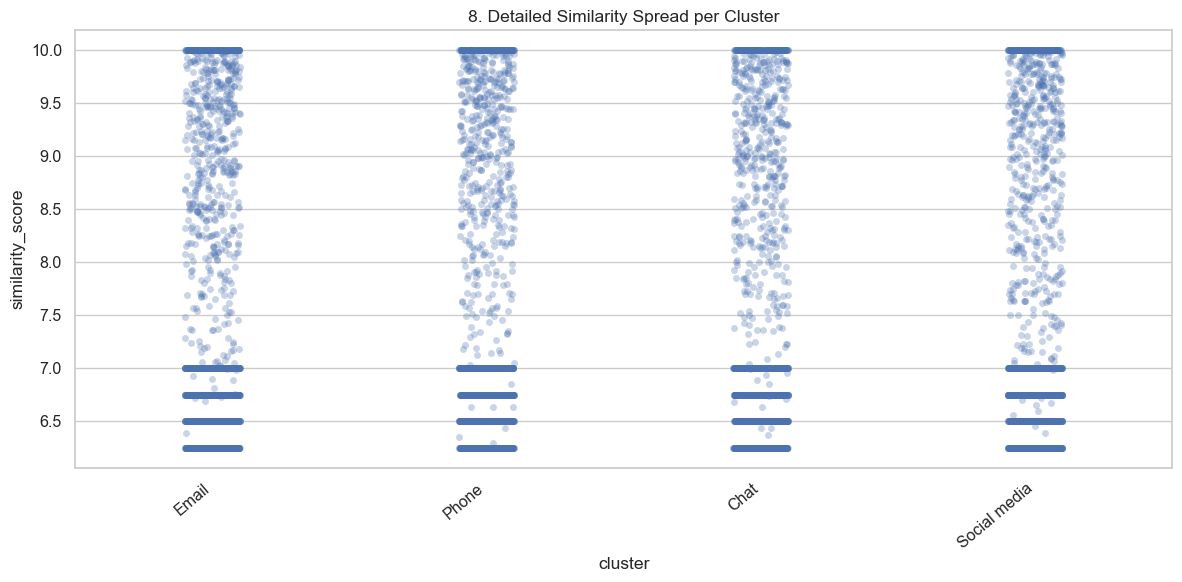

MODULE 4 – KEY OBSERVATIONS

Avg Resolution Duration by Cluster:
cluster
Chat            884.74
Email           892.29
Phone           889.22
Social media    870.34

Avg Similarity Score by Cluster:
cluster
Chat            7.46
Email           7.49
Phone           7.47
Social media    7.44

Ticket Count by Cluster:
cluster
Email           2143
Phone           2132
Social media    2121
Chat            2073

Module 4 Complete — 8 visualizations generated


In [46]:

# Module 4: Similarity and Cluster Insights
# Analyze average similarity scores within clusters
# Compare cluster size vs issue type
# Visualize performance gaps using boxplots and scatter plots
# Deliverables: Minimum 8 visualizations and summary of key patterns and problem clusters

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.figsize'] = (12, 6)

# --- CLEAN COLUMN NAMES FIRST ---
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()


print("Columns:", df.columns.tolist())

# --- CREATE PROXIES ---
df['cluster']          = df['ticket_channel']    # cluster proxy
df['similarity_score'] = df['performance_score'] # similarity proxy (use performance_score)

df_clean = df[df['resolution_duration'] >= 0].copy()

# Cluster ordering by average resolution time
cluster_order = (
    df_clean.groupby('cluster')['resolution_duration']
    .mean()
    .sort_values(ascending=False)
    .index
)

# --- PLOT 1: Average Similarity Score per Cluster ---
plt.figure()
avg_sim = df.groupby('cluster')['similarity_score'].mean().loc[cluster_order]
ax = sns.barplot(x=avg_sim.index, y=avg_sim.values,
                 hue=avg_sim.index, palette='viridis', legend=False)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=40, ha='right')
plt.ylabel("Average Similarity Score")
plt.title("1. Cluster Cohesion Analysis")
plt.tight_layout()
plt.show()

# --- PLOT 2: Similarity Score Distribution per Cluster ---
plt.figure()
sns.boxplot(data=df, x='cluster', y='similarity_score',
            order=cluster_order, showfliers=False)
plt.xticks(rotation=40, ha='right')
plt.title("2. Similarity Distribution Across Clusters")
plt.tight_layout()
plt.show()

# --- PLOT 3: Cluster Size (Ticket Volume) ---
plt.figure()
cluster_size = df['cluster'].value_counts().loc[cluster_order]
sns.barplot(x=cluster_size.index, y=cluster_size.values,
            hue=cluster_size.index, palette='coolwarm', legend=False)
plt.xticks(rotation=40, ha='right')
plt.ylabel("Ticket Count")
plt.title("3. Ticket Volume by Cluster")
plt.tight_layout()
plt.show()

# --- PLOT 4: Cluster vs Ticket Type (Heatmap) ---
plt.figure()
cluster_type = pd.crosstab(df['cluster'], df['ticket_type'])
sns.heatmap(cluster_type.loc[cluster_order], annot=True, fmt='d', cmap='Blues')
plt.title("4. Cluster vs Ticket Type Distribution")
plt.tight_layout()
plt.show()

# --- PLOT 5: Cluster vs Ticket Priority (Heatmap) ---
plt.figure()
cluster_priority = pd.crosstab(df['cluster'], df['ticket_priority'])
sns.heatmap(cluster_priority.loc[cluster_order], annot=True, fmt='d', cmap='Reds')
plt.title("5. Cluster vs Ticket Priority Distribution")
plt.tight_layout()
plt.show()

# --- PLOT 6: Similarity vs Resolution Duration (Scatter + Regression) ---
plt.figure()
sns.regplot(data=df_clean,
            x='resolution_duration',
            y='similarity_score',
            scatter_kws={'alpha': 0.2},
            line_kws={'color': 'black'})
plt.title("6. Efficiency Analysis: Similarity vs Resolution Time")
plt.tight_layout()
plt.show()

# --- PLOT 7: Resolution Duration by Cluster (Boxplot) ---
plt.figure()
sns.boxplot(data=df_clean, x='cluster', y='resolution_duration',
            order=cluster_order, showfliers=False)
plt.xticks(rotation=40, ha='right')
plt.title("7. Performance Gap Analysis")
plt.tight_layout()
plt.show()

# --- PLOT 8: Detailed Similarity Spread per Cluster (Stripplot) ---
plt.figure()
sns.stripplot(data=df, x='cluster', y='similarity_score',
              order=cluster_order, jitter=True, alpha=0.3)
plt.xticks(rotation=40, ha='right')
plt.title("8. Detailed Similarity Spread per Cluster")
plt.tight_layout()
plt.show()

# --- SUMMARY ---
print("=" * 50)
print("MODULE 4 – KEY OBSERVATIONS")
print("=" * 50)

print("\nAvg Resolution Duration by Cluster:")
print(df_clean.groupby('cluster')['resolution_duration'].mean().round(2).to_string())

print("\nAvg Similarity Score by Cluster:")
print(df.groupby('cluster')['similarity_score'].mean().round(2).to_string())

print("\nTicket Count by Cluster:")
print(df['cluster'].value_counts().to_string())

print("\nModule 4 Complete — 8 visualizations generated")

In [47]:
print(df.columns.tolist())

['ticket_id', 'customer_name', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_status', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'resolution_duration', 'priority_score', 'cluster', 'resolution_hours', 'performance_score', 'cluster_size', 'region', 'latitude', 'longitude', 'similarity_score']


In [48]:
# --- CLEAN COLUMNS FIRST ---
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# --- CHECK RESOLUTION HOURS ALREADY IN DATASET ---
print(df['resolution_hours'].describe().round(2))
print(df['resolution_duration'].describe().round(2))

count    2769.00
mean        7.74
std         5.61
min         0.00
25%         3.02
50%         6.70
75%        11.65
max        23.47
Name: resolution_hours, dtype: float64
count    8469.00
mean      288.44
std       432.55
min        -1.00
25%        -1.00
50%        -1.00
75%       691.00
max      1247.00
Name: resolution_duration, dtype: float64


Loaded: Supportlytics_Processed_Data.csv | Shape: (8469, 15)
Total: 8,469 | Closed: 2,769
Avg resolution_hours: 7.75


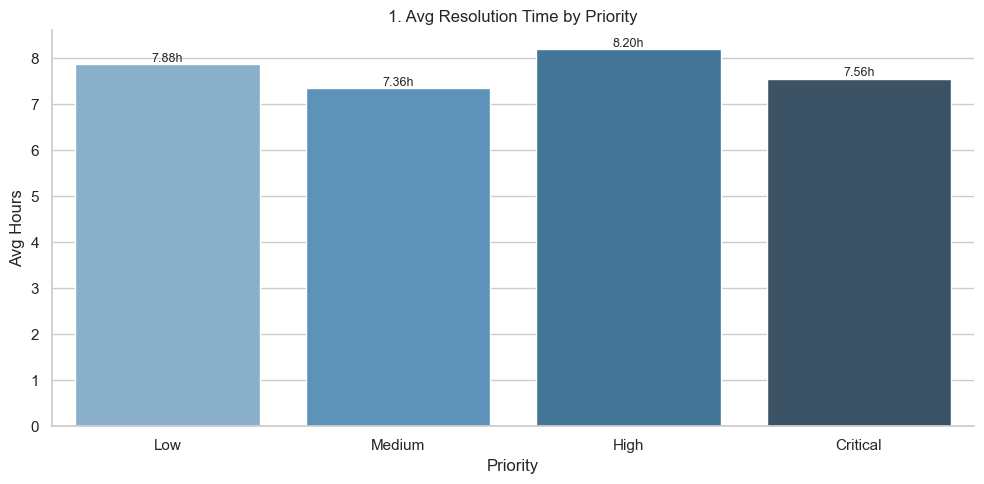

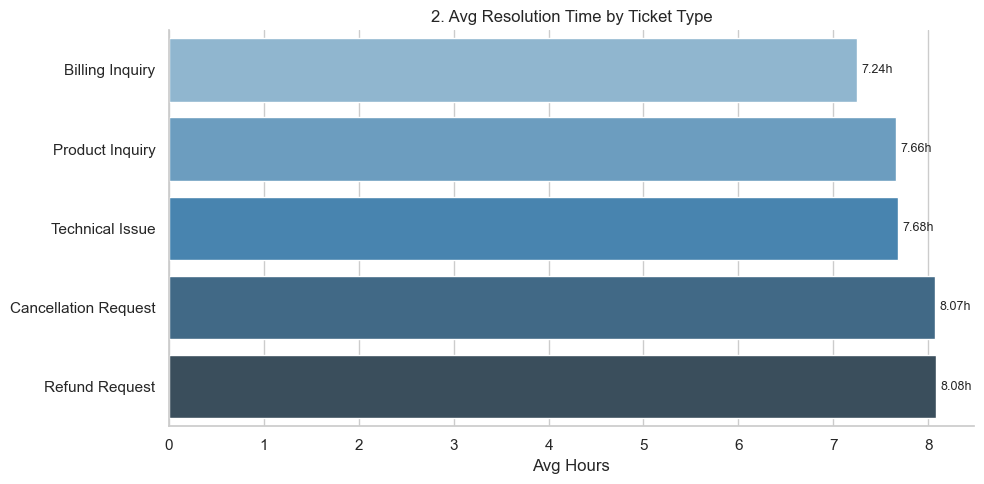

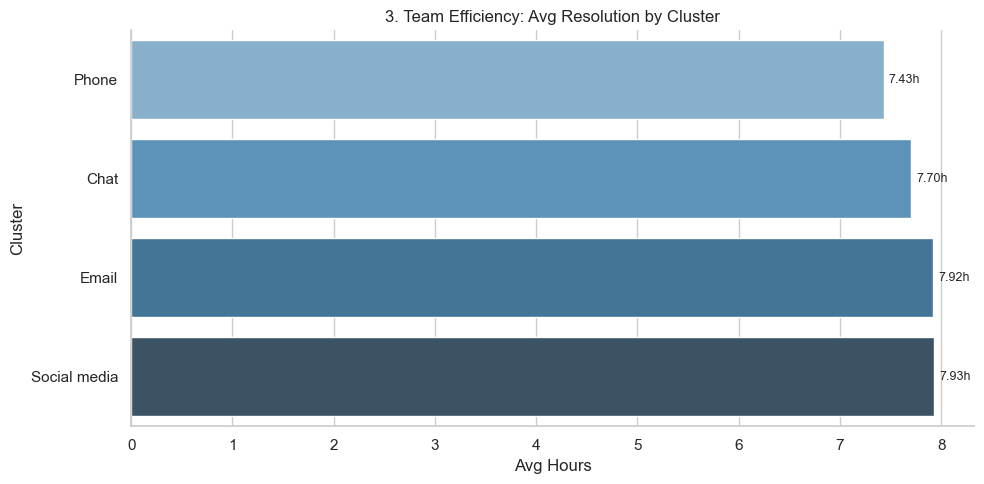

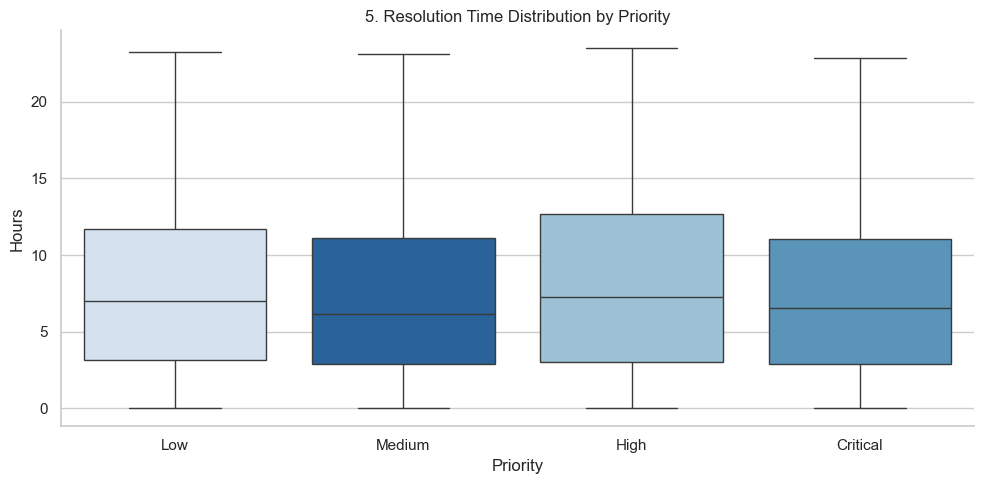

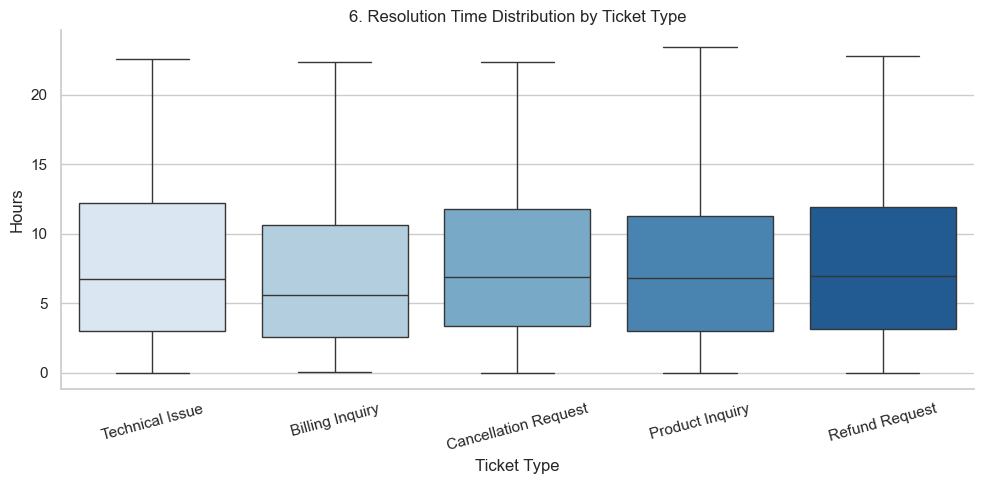

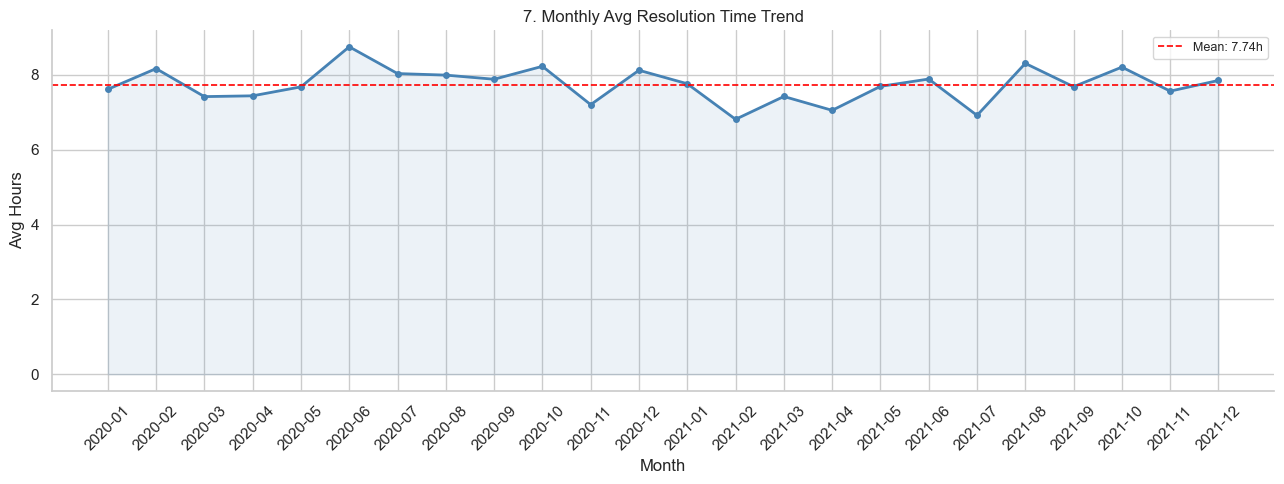

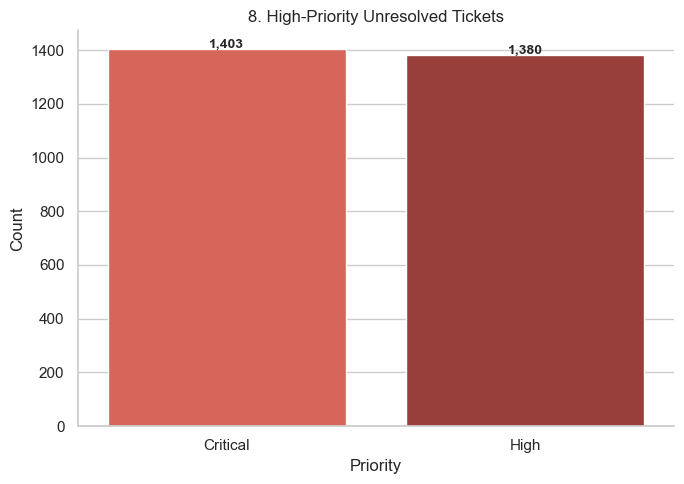

MODULE 5 - KPI SUMMARY
Total Tickets         : 8,469
Closed Tickets        : 2,769
High-Priority Backlog : 2,783
Avg Resolution (hrs)  : 7.75

Avg Resolution by Priority:
  Low         : 7.88 hrs
  Medium      : 7.36 hrs
  High        : 8.20 hrs
  Critical    : 7.56 hrs

Module 5 Complete


In [51]:
# Module 5: Performance Trend Analysis
# Analyze average resolution times by priority and type
# Determine which countries or teams handle tickets fastest
# Identify high-priority unresolved issues

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# --- LOAD DATA ---
for fname in ["Supportlytics_Processed_Data.csv", "clustered_tickets.csv",
              "customer_support_tickets.xlsx", "customer_support_tickets.csv"]:
    if os.path.exists(fname):
        df = pd.read_excel(fname) if fname.endswith(".xlsx") else pd.read_csv(fname)
        print(f"Loaded: {fname} | Shape: {df.shape}")
        break

# --- CLEAN COLUMNS ---
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# --- CREATE resolution_hours IF NOT PRESENT ---
if 'resolution_hours' not in df.columns:
    df['first_response_time'] = pd.to_datetime(df['first_response_time'], errors='coerce')
    df['time_to_resolution'] = pd.to_datetime(df['time_to_resolution'], errors='coerce')
    df['resolution_hours'] = (
        df['time_to_resolution'] - df['first_response_time']
    ).dt.total_seconds() / 3600
    df['resolution_hours'] = df['resolution_hours'].abs().round(2)

# --- USE EXISTING resolution_hours COLUMN DIRECTLY ---
# resolution_hours already exists in dataset (range: 0 to 23.47)
df['resolution_hours'] = pd.to_numeric(df['resolution_hours'], errors='coerce')
df['resolution_hours'] = df['resolution_hours'].where(df['resolution_hours'] > 0)

# --- PARSE DATE FOR MONTHLY TREND ---
df['date_of_purchase'] = pd.to_datetime(df['date_of_purchase'], errors='coerce')

# --- PROXIES ---
df['cluster'] = df['ticket_channel']

# --- FILTER CLOSED ---
closed = df[df['ticket_status'] == 'Closed'].copy()
print(f"Total: {len(df):,} | Closed: {len(closed):,}")
print(f"Avg resolution_hours: {df['resolution_hours'].mean():.2f}")

# --- PLOT 1: Avg Resolution by Priority ---
priority_order = [p for p in ['Low', 'Medium', 'High', 'Critical']
                  if p in closed['ticket_priority'].unique()]
p1 = closed.groupby('ticket_priority')['resolution_hours'].mean().loc[priority_order]

plt.figure()
ax = sns.barplot(x=p1.index, y=p1.values, hue=p1.index,
                 palette='Blues_d', legend=False)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.05,
            f'{p.get_height():.2f}h', ha='center', fontsize=9)
plt.title('1. Avg Resolution Time by Priority')
plt.xlabel('Priority')
plt.ylabel('Avg Hours')
plt.tight_layout()
plt.show()

# --- PLOT 2: Avg Resolution by Ticket Type ---
p2 = closed.groupby('ticket_type')['resolution_hours'].mean().sort_values()

plt.figure()
ax = sns.barplot(x=p2.values, y=p2.index, hue=p2.index,
                 palette='Blues_d', legend=False)
for p in ax.patches:
    ax.text(p.get_width() + 0.05, p.get_y() + p.get_height()/2,
            f'{p.get_width():.2f}h', va='center', fontsize=9)
plt.title('2. Avg Resolution Time by Ticket Type')
plt.xlabel('Avg Hours')
plt.ylabel('')
plt.tight_layout()
plt.show()

# --- PLOT 3: Fastest Clusters ---
p3 = closed.groupby('cluster')['resolution_hours'].mean().sort_values()

plt.figure()
ax = sns.barplot(x=p3.values, y=p3.index, hue=p3.index,
                 palette='Blues_d', legend=False)
for p in ax.patches:
    ax.text(p.get_width() + 0.05, p.get_y() + p.get_height()/2,
            f'{p.get_width():.2f}h', va='center', fontsize=9)
plt.title('3. Team Efficiency: Avg Resolution by Cluster')
plt.xlabel('Avg Hours')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

# --- PLOT 4: Region Resolution ---
if 'region' in df.columns:
    p4 = closed.groupby('region')['resolution_hours'].mean().sort_values()
    plt.figure()
    ax = sns.barplot(x=p4.values, y=p4.index, hue=p4.index,
                     palette='Blues_d', legend=False)
    for p in ax.patches:
        ax.text(p.get_width() + 0.05, p.get_y() + p.get_height()/2,
                f'{p.get_width():.2f}h', va='center', fontsize=9)
    plt.axvline(p4.mean(), color='red', linestyle='--', linewidth=1.2,
                label=f'Mean: {p4.mean():.2f}h')
    plt.title('4. Avg Resolution Time by Region')
    plt.xlabel('Avg Hours')
    plt.ylabel('Region')
    plt.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

# --- PLOT 5: Boxplot by Priority ---
plt.figure()
sns.boxplot(data=closed, x='ticket_priority', y='resolution_hours',
            order=priority_order, hue='ticket_priority',
            palette='Blues', showfliers=False, legend=False)
plt.title('5. Resolution Time Distribution by Priority')
plt.xlabel('Priority')
plt.ylabel('Hours')
plt.tight_layout()
plt.show()

# --- PLOT 6: Boxplot by Ticket Type ---
plt.figure()
sns.boxplot(data=closed, x='ticket_type', y='resolution_hours',
            hue='ticket_type',
            palette='Blues', showfliers=False, legend=False)
plt.title('6. Resolution Time Distribution by Ticket Type')
plt.xlabel('Ticket Type')
plt.ylabel('Hours')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# --- PLOT 7: Monthly Trend ---
df['month'] = df['date_of_purchase'].dt.to_period('M')
monthly = df.groupby('month')['resolution_hours'].mean().reset_index()
monthly['month_str'] = monthly['month'].astype(str)

plt.figure(figsize=(13, 5))
plt.plot(monthly['month_str'], monthly['resolution_hours'],
         color='steelblue', linewidth=2, marker='o', markersize=4)
plt.fill_between(monthly['month_str'], monthly['resolution_hours'],
                 alpha=0.1, color='steelblue')
plt.axhline(monthly['resolution_hours'].mean(), color='red', linestyle='--',
            linewidth=1.2, label=f"Mean: {monthly['resolution_hours'].mean():.2f}h")
plt.title('7. Monthly Avg Resolution Time Trend')
plt.xlabel('Month')
plt.ylabel('Avg Hours')
plt.xticks(rotation=45)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- PLOT 8: High-Priority Unresolved ---
unresolved = df[
    (df['ticket_priority'].isin(['High', 'Critical'])) &
    (df['ticket_status'] != 'Closed')
]
pending = unresolved['ticket_priority'].value_counts()

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=pending.index, y=pending.values, hue=pending.index,
                 palette='Reds_d', legend=False)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 5,
            f'{int(p.get_height()):,}', ha='center', fontsize=10, fontweight='bold')
plt.title('8. High-Priority Unresolved Tickets')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# --- KPI SUMMARY ---
print("MODULE 5 - KPI SUMMARY")
print(f"Total Tickets         : {len(df):,}")
print(f"Closed Tickets        : {len(closed):,}")
print(f"High-Priority Backlog : {len(unresolved):,}")
print(f"Avg Resolution (hrs)  : {df['resolution_hours'].mean():.2f}")
print("\nAvg Resolution by Priority:")
for p in ['Low', 'Medium', 'High', 'Critical']:
    val = closed[closed['ticket_priority'] == p]['resolution_hours'].mean()
    if pd.notna(val):
        print(f"  {p:<12}: {val:.2f} hrs")
print("\nModule 5 Complete")

In [58]:
# 1. Save the processed dataframe to a CSV file
# We exclude the index to keep the file clean for future loading
output_file = 'Supportlytics_Final_Data.csv'
df.to_csv(output_file, index=False)

import os
if os.path.exists(output_file):
    print(f"Success: Final dataset saved as '{output_file}'")
    print(f"File size: {os.path.getsize(output_file) / 1024:.2f} KB")
else:
    print("Error: File was not saved correctly.")

print(f"Total Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print(f"New Features Created: Resolution_Duration, Priority_Score,")
print(f"                      resolution_hours, Performance_Score,")
print(f"                      Cluster_Size, Region, Latitude, Longitude")
print("Cleaned data is exported")

Success: Final dataset saved as 'Supportlytics_Final_Data.csv'
File size: 1456.50 KB
Total Records: 8469
Total Features: 21
New Features Created: Resolution_Duration, Priority_Score,
                      resolution_hours, Performance_Score,
                      Cluster_Size, Region, Latitude, Longitude
Cleaned data is exported


In [54]:
import pandas as pd

df = pd.read_csv("Supportlytics_Final_Data.csv")
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
print(df.shape)
print(df.columns.tolist())

(8469, 21)
['ticket_id', 'customer_name', 'customer_age', 'customer_gender', 'product_purchased', 'date_of_purchase', 'ticket_type', 'ticket_subject', 'ticket_status', 'ticket_priority', 'ticket_channel', 'first_response_time', 'time_to_resolution', 'resolution_duration', 'priority_score', 'resolution_hours', 'region', 'latitude', 'longitude', 'cluster_size', 'performance_score']


In [55]:
import pandas as pd

# Read the CSV version
df = pd.read_csv("Supportlytics_Final_Data.csv")

# Save to the correct folder
df.to_csv(
    r"C:\Users\natur\OneDrive\Data visualisation project\Supportlytics_Final_Data.csv",
    index=False
)
print("Done! File saved.")

Done! File saved.
